# Migrating to the new LSEG ESG Scores: a practical portfolio implementation guide

Code companion for the article of [Migrating to the new LSEG ESG Scores: a practical portfolio implementation guide](https://developers.lseg.com/en/article-catalog/article/migrating-to-new-esg-scores-data-library), using the [LSEG Data Library for Python](https://developers.lseg.com/en/api-catalog/lseg-data-platform/lseg-data-library-for-python/) through an LSEG Workspace desktop session.

**Prerequisites**
- LSEG Workspace running and logged in on the same machine
- Python 3.9+ with the libraries in `requirements.txt`

> The new LSEG ESG Scores are not a rescaled version of the legacy scores. Dividing legacy scores by 20 is used for charts only.

In [1]:
import lseg.data as ld
import pandas as pd
import matplotlib.pyplot as plt
from lseg.data.discovery import Chain

# Silences a pandas FutureWarning raised inside lseg-data
pd.set_option("future.no_silent_downcasting", True)

ld.open_session()

<lseg.data.session.Definition object at 0x271fd879fa0 {name='workspace'}>

## 5) Build the migration dataset

### 5.1) Define the portfolio

We use the FTSE 100 constituents as a sample portfolio of ~100 companies, weighted by market capitalisation.
To use your own holdings, replace `universe` with your list of RICs and `Weight` with your portfolio weights.

In [2]:
universe = Chain(name="0#.FTSE").constituents

portfolio = ld.get_data(universe, ["TR.CommonName", "TR.TRBCEconomicSector", "TR.CompanyMarketCap"])

portfolio["Weight"] = portfolio["Company Market Cap"] / portfolio["Company Market Cap"].sum()
portfolio.head()

,Instrument,Company Common Name,TRBC Economic Sector Name,Company Market Cap,Weight
0,AAF.L,Airtel Africa PLC,Technology,11285681440.360001,0.004054
1,AAL.L,Anglo American PLC,Basic Materials,47027766858.239998,0.016895
2,ABDN.L,Aberdeen Group PLC,Financials,4528235713.5,0.001627
3,ABF.L,Associated British Foods PLC,Consumer Non-Cyclicals,13074817752.6,0.004697
4,ADML.L,Admiral Group PLC,Financials,11106607551.76,0.00399


### 5.2) Retrieve legacy ESG Scores

The legacy Overall and Pillar scores (0-100) and the score date.

In [3]:
legacy = ld.get_data(
    universe,
    [
        "TR.TRESGScore",
        "TR.TRESGScore.date",
        "TR.TRESGCScore",
        "TR.TRESGCControversiesScore",
        "TR.EnvironmentPillarScore",
        "TR.SocialPillarScore",
        "TR.GovernancePillarScore",
    ],

)
legacy.head()

,Instrument,ESG Score,Date,ESG Combined Score,ESG Controversies Score,Environmental Pillar Score,Social Pillar Score,Governance Pillar Score
0,AAF.L,64.060468,2025-03-31,64.060468,100.0,54.248977,69.360028,60.954051
1,AAL.L,73.629064,2025-12-31,58.12135,42.613636,61.300312,80.236602,80.471254
2,ABDN.L,76.093283,2025-12-31,76.093283,100.0,44.172304,82.599252,80.175648
3,ABF.L,69.763059,2025-09-13,41.80924,13.855422,83.869436,63.892762,64.388611
4,ADML.L,57.332536,2025-12-31,57.332536,100.0,63.839421,44.555232,70.070429


### 5.3) Retrieve new Overall and Pillar Scores

The new Overall ESG Score and the E, S and G Pillar Scores (0-5).

In [4]:
new = ld.get_data(
    universe,
    [
        "TR.ESGScore",
        "TR.ESGScore.date",
        "TR.EnvironmentalPillarESGScore",
        "TR.SocialPillarESGScore",
        "TR.GovernancePillarESGScore",
    ],
)
new.head()

,Instrument,LSEG ESG Score,Date,Environmental Pillar ESG Score,Social Pillar ESG Score,Governance Pillar ESG Score
0,AAF.L,3.565217,2025-03-31,2.75,3.5,3.818182
1,AAL.L,4.04175,2025-12-31,3.857143,4.0,4.230769
2,ABDN.L,3.597315,2025-12-31,4.0,2.5,3.714286
3,ABF.L,2.762397,2025-09-13,3.0,2.0,3.375
4,ADML.L,2.818792,2025-12-31,3.75,1.5,2.857143


### 5.4) Retrieve Themes and materiality

Add the Theme Score and materiality field codes from the Workspace Data Item Browser to the list below.

In [5]:
theme_fields = []  # e.g. Theme Score and Theme materiality field codes

if theme_fields:
    themes = ld.get_data(universe, theme_fields)
    display(themes.head())

### 5.5) Retrieve ESG Scores Plus

The three ESG Scores Plus lenses: Complete, Risk and Impact.

In [6]:
plus = ld.get_data(
    universe,
    [
        "TR.ESGPlusCompleteScore",
        "TR.ESGPlusRiskScore",
        "TR.ESGPlusImpactScore",
        "TR.GreenRevenuesScore",
        "TR.GreenIssuanceScore",
        "TR.ControversiesScore",
        "TR.ESGIssuanceScore",
        "TR.SovereignRiskScore",
    ],
)
plus.head()

,Instrument,LSEG ESG Score Plus,LSEG ESG Score Plus Risk Oriented,LSEG ESG Score Plus Impact Oriented,Green Revenues Score,Green Issuance Score,Controversies Score,ESG Issuance Score,Sovereign Risk Score
0,AAF.L,3.735962,3.735962,3.6,0.0,0.0,0.0,0.0,3.88617
1,AAL.L,2.680583,2.510211,4.0,0.0,0.0,3.414988,1.703716,3.523305
2,ABDN.L,3.73146,3.73146,3.6,0.0,0.0,0.0,0.0,3.860818
3,ABF.L,2.995623,2.986822,2.8088,0.02657,0.0,0.0,0.0,3.790009
4,ADML.L,3.023573,3.023573,2.8,0.0,0.0,0.0,0.0,3.921711


### 5.6) Join and prepare the migration dataset

We merge everything on `Instrument`, check coverage and score dates, and keep only companies with both a legacy and a new ESG Score.
Both legacy and new data return a `Date` column, so the merge labels them `Date (legacy)` and `Date (new)`.

In [7]:
data = (
    portfolio
    .merge(legacy, on="Instrument")
    .merge(new, on="Instrument", suffixes=(" (legacy)", " (new)"))
    .merge(plus, on="Instrument")
)

legacy_scores = ["ESG Score", "ESG Combined Score", "ESG Controversies Score",
                 "Environmental Pillar Score", "Social Pillar Score", "Governance Pillar Score"]
new_scores = ["LSEG ESG Score", "Environmental Pillar ESG Score", "Social Pillar ESG Score", "Governance Pillar ESG Score"]
plus_scores = ["LSEG ESG Score Plus", "LSEG ESG Score Plus Risk Oriented", "LSEG ESG Score Plus Impact Oriented",
               "Green Revenues Score", "Green Issuance Score", "Controversies Score", "ESG Issuance Score", "Sovereign Risk Score"]
score_columns = legacy_scores + new_scores + plus_scores

data[score_columns] = data[score_columns].apply(pd.to_numeric, errors="coerce")

# Coverage: share of companies with a value for each field
data.notna().mean().round(2)

Instrument                             1.00
Company Common Name                    1.00
TRBC Economic Sector Name              1.00
Company Market Cap                     1.00
Weight                                 1.00
ESG Score                              0.99
Date (legacy)                          0.99
ESG Combined Score                     0.99
ESG Controversies Score                0.99
Environmental Pillar Score             0.99
Social Pillar Score                    0.99
Governance Pillar Score                0.99
LSEG ESG Score                         0.98
Date (new)                             0.98
Environmental Pillar ESG Score         0.98
Social Pillar ESG Score                0.99
Governance Pillar ESG Score            0.99
LSEG ESG Score Plus                    0.99
LSEG ESG Score Plus Risk Oriented      0.99
LSEG ESG Score Plus Impact Oriented    0.99
Green Revenues Score                   0.99
Green Issuance Score                   0.99
Controversies Score             

The table above (`data.notna().mean()`) shows, for each field, the share of companies (0 to 1) that have a value. A field close to 1.0 has good coverage across the portfolio; a low value means many companies are missing that score and results based on it will rely on fewer holdings.

Next we check whether the legacy and new scores refer to comparable periods.

In [8]:
# Score years: check both methodologies refer to comparable periods
legacy_year = pd.to_datetime(data["Date (legacy)"]).dt.year
new_year = pd.to_datetime(data["Date (new)"]).dt.year
pd.crosstab(legacy_year, new_year, rownames=["Legacy score year"], colnames=["New score year"])

New score year,2024.0,2025.0,2026.0
Legacy score year,,,
2024.0,10,0,0
2025.0,0,84,0
2026.0,0,0,4


The crosstab above is a matrix: rows are the legacy score year, columns are the new score year, and each cell counts the companies with that combination. Most companies should sit on the diagonal (same year for both scores); many off-diagonal companies would mean the two scores are not always comparable period-for-period.

We now keep only the companies that have both a legacy and a new Overall ESG Score, and rescale their weights so they sum back to 1 within this smaller set.

In [9]:
df = data.dropna(subset=["ESG Score", "LSEG ESG Score"]).copy()
df["Weight"] = df["Weight"] / df["Weight"].sum()

print(f"Companies in portfolio: {len(data)}, with both scores: {len(df)}")
df.head()

Companies in portfolio: 100, with both scores: 98


,Instrument,Company Common Name,TRBC Economic Sector Name,Company Market Cap,Weight,ESG Score,Date (legacy),ESG Combined Score,ESG Controversies Score,Environmental Pillar Score,...,Social Pillar ESG Score,Governance Pillar ESG Score,LSEG ESG Score Plus,LSEG ESG Score Plus Risk Oriented,LSEG ESG Score Plus Impact Oriented,Green Revenues Score,Green Issuance Score,Controversies Score,ESG Issuance Score,Sovereign Risk Score
0,AAF.L,Airtel Africa PLC,Technology,11285681440.360001,0.004071,64.060468,2025-03-31,64.060468,100.0,54.248977,...,3.5,3.818182,3.735962,3.735962,3.6,0.0,0.0,0.0,0.0,3.88617
1,AAL.L,Anglo American PLC,Basic Materials,47027766858.239998,0.016964,73.629064,2025-12-31,58.12135,42.613636,61.300312,...,4.0,4.230769,2.680583,2.510211,4.0,0.0,0.0,3.414988,1.703716,3.523305
2,ABDN.L,Aberdeen Group PLC,Financials,4528235713.5,0.001633,76.093283,2025-12-31,76.093283,100.0,44.172304,...,2.5,3.714286,3.73146,3.73146,3.6,0.0,0.0,0.0,0.0,3.860818
3,ABF.L,Associated British Foods PLC,Consumer Non-Cyclicals,13074817752.6,0.004716,69.763059,2025-09-13,41.80924,13.855422,83.869436,...,2.0,3.375,2.995623,2.986822,2.8088,0.02657,0.0,0.0,0.0,3.790009
4,ADML.L,Admiral Group PLC,Financials,11106607551.76,0.004006,57.332536,2025-12-31,57.332536,100.0,63.839421,...,1.5,2.857143,3.023573,3.023573,2.8,0.0,0.0,0.0,0.0,3.921711


## 6) Run a portfolio migration diagnostic

### 6.1) Compare portfolio distributions

`ESG Score` is the legacy score (0-100) and `LSEG ESG Score` is the new score (0-5). Legacy scores are divided by 20 **for the chart only**.

In [10]:
df[["ESG Score", "LSEG ESG Score"]].describe().round(2)

,ESG Score,LSEG ESG Score
count,98.0,98.0
mean,70.01,3.44
std,13.34,0.72
min,18.86,1.23
25%,64.82,3.11
50%,72.83,3.54
75%,79.18,3.93
max,89.89,4.76


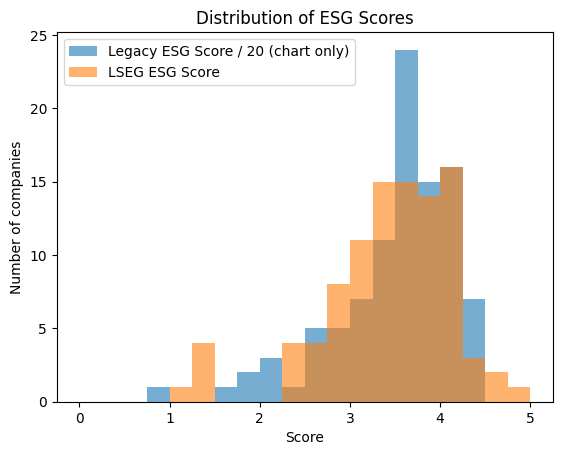

In [11]:
plt.hist(df["ESG Score"] / 20, bins=20, range=(0, 5), alpha=0.6, label="Legacy ESG Score / 20 (chart only)")
plt.hist(df["LSEG ESG Score"], bins=20, range=(0, 5), alpha=0.6, label="LSEG ESG Score")
plt.title("Distribution of ESG Scores")
plt.xlabel("Score")
plt.ylabel("Number of companies")
plt.legend()
plt.show()

### 6.2) Measure ranking changes

Since the two scales are different, we compare **positions** in the portfolio: correlation, percentile ranks and quartiles.

In [12]:
print("Correlation:", round(df["ESG Score"].corr(df["LSEG ESG Score"]), 2))
print("Rank correlation:", round(df["ESG Score"].corr(df["LSEG ESG Score"], method="spearman"), 2))

# Percentile rank: 0 = lowest score in the portfolio, 1 = highest
df["Rank Legacy"] = df["ESG Score"].rank(pct=True)
df["Rank New"] = df["LSEG ESG Score"].rank(pct=True)
df["Rank Change"] = df["Rank New"] - df["Rank Legacy"]

quartiles = ["Q4 (bottom)", "Q3", "Q2", "Q1 (top)"]
df["Quartile Legacy"] = pd.qcut(df["ESG Score"].rank(method="first"), 4, labels=quartiles)
df["Quartile New"] = pd.qcut(df["LSEG ESG Score"].rank(method="first"), 4, labels=quartiles)

pd.crosstab(df["Quartile Legacy"], df["Quartile New"])

Correlation: 0.75
Rank correlation: 0.62


Quartile New,Q4 (bottom),Q3,Q2,Q1 (top)
Quartile Legacy,,,,
Q4 (bottom),16,6,3,0
Q3,7,5,7,5
Q2,2,8,7,7
Q1 (top),0,5,7,13


The crosstab above is a matrix: rows are the legacy quartile, columns are the new quartile, and each cell is the number of companies in that combination. Numbers on the diagonal are companies that stayed in the same quartile; numbers off the diagonal moved quartile after the transition.

Next, we list the companies that moved into or out of the top and bottom quartiles.

In [13]:
columns = ["Company Common Name", "ESG Score", "LSEG ESG Score", "Quartile Legacy", "Quartile New"]

print("Moved into the top quartile")
display(df[(df["Quartile New"] == "Q1 (top)") & (df["Quartile Legacy"] != "Q1 (top)")][columns])

print("Moved into the bottom quartile")
display(df[(df["Quartile New"] == "Q4 (bottom)") & (df["Quartile Legacy"] != "Q4 (bottom)")][columns])

Moved into the top quartile


,Company Common Name,ESG Score,LSEG ESG Score,Quartile Legacy,Quartile New
1,Anglo American PLC,73.629064,4.04175,Q2,Q1 (top)
8,Aviva PLC,72.388903,4.147651,Q3,Q1 (top)
12,Barclays PLC,70.679563,4.110738,Q3,Q1 (top)
21,BT Group PLC,67.726141,4.094862,Q3,Q1 (top)
24,Coca-Cola Europacific Partners PLC,78.310553,3.934091,Q2,Q1 (top)
31,Diageo PLC,75.358569,4.1,Q2,Q1 (top)
35,Experian PLC,73.381224,4.14094,Q2,Q1 (top)
51,Imperial Brands PLC,73.749224,4.10076,Q2,Q1 (top)
59,Legal & General Group PLC,72.945683,4.097315,Q2,Q1 (top)
62,London Stock Exchange Group PLC,72.438393,4.583893,Q3,Q1 (top)


Moved into the bottom quartile


,Company Common Name,ESG Score,LSEG ESG Score,Quartile Legacy,Quartile New
3,Associated British Foods PLC,69.763059,2.762397,Q3,Q4 (bottom)
22,Barratt Redrow PLC,67.134245,2.885106,Q3,Q4 (bottom)
34,Entain PLC,69.030597,2.886598,Q3,Q4 (bottom)
63,Marks and Spencer Group PLC,70.690691,2.913223,Q3,Q4 (bottom)
69,Next PLC,66.104001,2.953608,Q3,Q4 (bottom)
73,Persimmon PLC,71.287816,2.731915,Q3,Q4 (bottom)
91,SSE PLC,74.507211,3.023404,Q2,Q4 (bottom)
98,Weir PLC,67.795836,3.060914,Q3,Q4 (bottom)
99,Whitbread PLC,77.534149,2.487113,Q2,Q4 (bottom)


### 6.3) Identify the largest movers

The largest movers are the companies whose rank changed the most. We then look at which Pillar moved the most.

In [14]:
pillars = {
    "E": ("Environmental Pillar Score", "Environmental Pillar ESG Score"),
    "S": ("Social Pillar Score", "Social Pillar ESG Score"),
    "G": ("Governance Pillar Score", "Governance Pillar ESG Score"),
}
for pillar, (legacy_column, new_column) in pillars.items():
    df[f"Rank Change {pillar}"] = df[new_column].rank(pct=True) - df[legacy_column].rank(pct=True)

columns = ["Company Common Name", "TRBC Economic Sector Name", "ESG Score", "LSEG ESG Score",
           "Rank Change", "Rank Change E", "Rank Change S", "Rank Change G"]

print("Largest upward movers")
display(df.nlargest(10, "Rank Change")[columns].round(2))

print("Largest downward movers")
display(df.nsmallest(10, "Rank Change")[columns].round(2))

Largest upward movers


,Company Common Name,TRBC Economic Sector Name,ESG Score,LSEG ESG Score,Rank Change,Rank Change E,Rank Change S,Rank Change G
21,BT Group PLC,Technology,67.73,4.09,0.53,0.17,0.51,0.30
82,Schroders PLC,Financials,65.08,4.01,0.52,0.05,0.56,0.19
87,Smiths Group PLC,Consumer Non-Cyclicals,53.16,3.75,0.51,0.34,0.66,0.44
62,London Stock Exchange Group PLC,Financials,72.44,4.58,0.49,0.48,0.30,0.53
67,National Grid PLC,Utilities,63.6,3.92,0.49,0.30,0.27,0.60
12,Barclays PLC,Financials,70.68,4.11,0.48,-0.22,0.36,0.46
8,Aviva PLC,Financials,72.39,4.15,0.42,0.38,0.29,-0.08
35,Experian PLC,Industrials,73.38,4.14,0.36,0.06,-0.17,0.16
59,Legal & General Group PLC,Financials,72.95,4.1,0.34,0.13,0.12,0.23
26,Centrica PLC,Utilities,70.13,3.86,0.33,0.12,0.30,0.24


Largest downward movers


,Company Common Name,TRBC Economic Sector Name,ESG Score,LSEG ESG Score,Rank Change,Rank Change E,Rank Change S,Rank Change G
58,Land Securities Group PLC,Real Estate,86.68,3.14,-0.64,-0.38,-0.72,-0.36
99,Whitbread PLC,Consumer Cyclicals,77.53,2.49,-0.61,-0.61,-0.52,-0.35
92,Standard Chartered PLC,Financials,87.48,3.41,-0.52,0.17,-0.39,-0.77
9,AstraZeneca PLC,Healthcare,89.89,3.53,-0.50,0.08,-0.65,-0.41
96,United Utilities Group PLC,Utilities,80.16,3.37,-0.40,-0.25,-0.30,0.04
33,Endeavour Mining plc,Basic Materials,82.05,3.52,-0.39,-0.04,-0.19,-0.53
89,Smith & Nephew PLC,Healthcare,83.31,3.59,-0.39,-0.04,-0.42,-0.11
20,Burberry Group PLC,Consumer Cyclicals,88.31,3.64,-0.36,-0.45,-0.21,-0.02
91,SSE PLC,Utilities,74.51,3.02,-0.36,-0.04,-0.55,-0.18
6,Antofagasta PLC,Basic Materials,77.43,3.27,-0.35,-0.21,-0.29,-0.08


### 6.4) Identify companies crossing investment thresholds

Existing rule: exclude companies with a legacy ESG Score below 30. We compare it with several thresholds on the new score instead of simply using 30 / 20 = 1.5.

In [15]:
LEGACY_THRESHOLD = 30
df["Excluded Legacy"] = df["ESG Score"] < LEGACY_THRESHOLD
print(f"Legacy rule excludes {df['Excluded Legacy'].sum()} companies")

# New-score threshold that excludes the same number of companies
same_count_threshold = df["LSEG ESG Score"].quantile(df["Excluded Legacy"].mean())
print(f"New-score threshold with the same exclusion rate: {same_count_threshold:.2f}")

Legacy rule excludes 1 companies
New-score threshold with the same exclusion rate: 1.38


In [16]:
results = []
for threshold in [1.0, 1.5, 2.0, 2.5, 3.0, round(same_count_threshold, 2)]:
    excluded_new = df["LSEG ESG Score"] < threshold
    results.append({
        "New threshold": threshold,
        "Excluded": excluded_new.sum(),
        "Weight excluded": df.loc[excluded_new, "Weight"].sum().round(3),
        "Newly excluded": (excluded_new & ~df["Excluded Legacy"]).sum(),
        "Newly eligible": (~excluded_new & df["Excluded Legacy"]).sum(),
    })

pd.DataFrame(results)

,New threshold,Excluded,Weight excluded,Newly excluded,Newly eligible
0,1.00,0,0.000,0,1
1,1.50,5,0.015,4,0
2,2.00,5,0.015,4,0
3,2.50,9,0.022,8,0
4,3.00,21,0.054,20,0
5,1.38,4,0.009,4,1


The table above compares candidate thresholds on the new score. For each one: `Excluded` and `Weight excluded` show how strict the rule would be; `Newly excluded` are companies that pass the legacy rule but would be excluded under the new one; `Newly eligible` are companies excluded today that would pass under the new rule. Use this to pick a threshold, rather than assuming 30 / 20 = 1.5.

In [17]:
# Pick a threshold after reviewing the table above, then list the companies whose eligibility changes
NEW_THRESHOLD = 1.5
df["Excluded New"] = df["LSEG ESG Score"] < NEW_THRESHOLD

changed = df[df["Excluded Legacy"] != df["Excluded New"]]
changed[["Company Common Name", "TRBC Economic Sector Name", "ESG Score", "LSEG ESG Score",
         "Excluded Legacy", "Excluded New", "Rank Change E", "Rank Change S", "Rank Change G"]].round(2)

,Company Common Name,TRBC Economic Sector Name,ESG Score,LSEG ESG Score,Excluded Legacy,Excluded New,Rank Change E,Rank Change S,Rank Change G
5,Alliance Witan PLC,Financials,49.19,1.38,False,True,-0.08,-0.20,-0.04
36,F&C Investment Trust PLC,Financials,35.58,1.23,False,True,-0.04,-0.15,-0.01
70,Polar Capital Technology Trust PLC,Financials,42.03,1.38,False,True,-0.01,-0.03,-0.05
72,Pershing Square Holdings Ltd,Financials,33.27,1.38,False,True,0.02,-0.36,0.02


### 6.5) Assess portfolio and sector impacts

We compare the simple average of each score with the market-cap-weighted average (using `weighted_average`), then look at the same comparison by sector, and finally at how each exclusion rule changes the investable universe.

In [18]:
def weighted_average(data, column):
    valid = data.dropna(subset=[column])
    return (valid[column] * valid["Weight"]).sum() / valid["Weight"].sum()

pd.DataFrame({
    "Average": df[score_columns].mean(),
    "Weighted average": [weighted_average(df, c) for c in score_columns],
}).round(2)

,Average,Weighted average
ESG Score,70.01,76.73
ESG Combined Score,61.07,57.82
ESG Controversies Score,70.09,46.82
Environmental Pillar Score,65.95,75.47
Social Pillar Score,70.04,77.69
Governance Pillar Score,72.73,77.02
LSEG ESG Score,3.44,3.77
Environmental Pillar ESG Score,3.18,3.51
Social Pillar ESG Score,2.93,3.42
Governance Pillar ESG Score,3.9,4.11


Now the same comparison broken down by sector: number of companies, portfolio weight, and average percentile rank under the legacy and new scores. `Rank_Change` is positive for sectors that moved up in relative ranking after the transition, negative for sectors that moved down.

In [19]:
sectors = df.groupby("TRBC Economic Sector Name").agg(
    Companies=("Company Common Name", "count"),
    Weight=("Weight", "sum"),
    Rank_Legacy=("Rank Legacy", "mean"),
    Rank_New=("Rank New", "mean"),
)
sectors["Rank_Change"] = sectors["Rank_New"] - sectors["Rank_Legacy"]
sectors.sort_values("Weight", ascending=False).round(2)

,Companies,Weight,Rank_Legacy,Rank_New,Rank_Change
TRBC Economic Sector Name,,,,,
Financials,26,0.26,0.46,0.55,0.09
Consumer Non-Cyclicals,13,0.14,0.57,0.56,-0.01
Basic Materials,7,0.12,0.67,0.60,-0.07
Healthcare,5,0.11,0.71,0.52,-0.20
Industrials,14,0.11,0.42,0.48,0.06
Energy,2,0.11,0.87,0.80,-0.07
Consumer Cyclicals,13,0.05,0.41,0.24,-0.17
Technology,8,0.05,0.49,0.66,0.16
Utilities,5,0.04,0.50,0.56,0.06


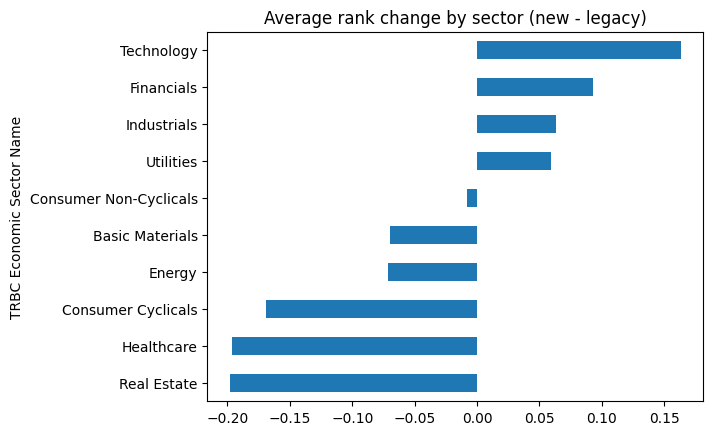

In [20]:
sectors["Rank_Change"].sort_values().plot.barh(title="Average rank change by sector (new - legacy)")
plt.show()

Finally, we compare the two exclusion rules from section 5.4 on the whole portfolio: how many companies each rule keeps, how much portfolio weight it excludes, and the weighted ESG Scores Plus Risk and Impact of the companies that remain.

In [21]:
# Impact of each exclusion rule on the investable universe
risk, impact = "LSEG ESG Score Plus Risk Oriented", "LSEG ESG Score Plus Impact Oriented"

pd.DataFrame({
    f"Legacy < {LEGACY_THRESHOLD}": {
        "Companies kept": (~df["Excluded Legacy"]).sum(),
        "Weight excluded": df.loc[df["Excluded Legacy"], "Weight"].sum(),
        "Plus Risk (kept, weighted)": weighted_average(df[~df["Excluded Legacy"]], risk),
        "Plus Impact (kept, weighted)": weighted_average(df[~df["Excluded Legacy"]], impact),
    },
    f"New < {NEW_THRESHOLD}": {
        "Companies kept": (~df["Excluded New"]).sum(),
        "Weight excluded": df.loc[df["Excluded New"], "Weight"].sum(),
        "Plus Risk (kept, weighted)": weighted_average(df[~df["Excluded New"]], risk),
        "Plus Impact (kept, weighted)": weighted_average(df[~df["Excluded New"]], impact),
    },
}).round(3)

,Legacy < 30,New < 1.5
Companies kept,97.000,93.000
Weight excluded,0.006,0.015
"Plus Risk (kept, weighted)",3.178,3.193
"Plus Impact (kept, weighted)",3.824,3.847


## 7. Explain a score change: worked company example

Portfolio -> Company -> Overall -> Pillar -> Theme -> Indicator -> Data -> Risk / Impact

We pick the company with the largest rank change.

In [22]:
company = df.loc[df["Rank Change"].abs().idxmax()]
print(company["Company Common Name"], "-", company["TRBC Economic Sector Name"])

Land Securities Group PLC - Real Estate


## 7) Explain a score change: worked company example
### 7.1) Start with the Overall ESG Score

Legacy and new Overall scores for this company, their percentile rank in the portfolio, the rank change, and which quartile they fall in under each methodology.

In [23]:
company[["ESG Score", "LSEG ESG Score", "Rank Legacy", "Rank New", "Rank Change", "Quartile Legacy", "Quartile New"]]

ESG Score          86.679359
LSEG ESG Score      3.141243
Rank Legacy         0.938776
Rank New            0.295918
Rank Change        -0.642857
Quartile Legacy     Q1 (top)
Quartile New              Q3
Name: 58, dtype: object

### 7.2) Move to the Pillars

For each Pillar (Environmental, Social, Governance), we show the legacy score, new score, and rank change, then chart which Pillar moved the most and in which direction.

In [24]:
pillar_view = pd.DataFrame({
    "Legacy score": [company[legacy_column] for legacy_column, _ in pillars.values()],
    "New score": [company[new_column] for _, new_column in pillars.values()],
    "Rank change": [company[f"Rank Change {p}"] for p in pillars],
}, index=["Environmental", "Social", "Governance"])

pillar_view.round(2)

,Legacy score,New score,Rank change
Environmental,92.15,3.42,-0.38
Social,91.66,2.33,-0.72
Governance,75.62,3.20,-0.36


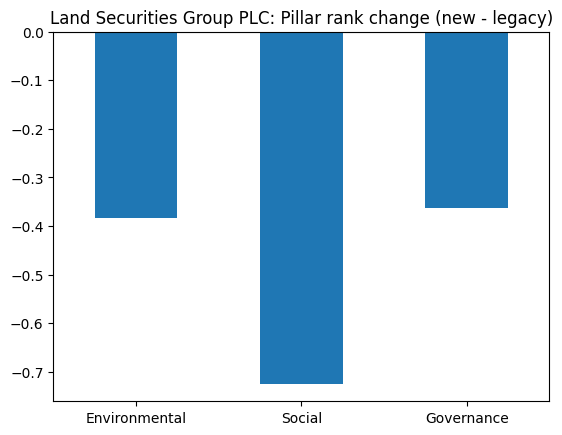

In [25]:
pillar_view["Rank change"].plot.bar(title=f"{company['Company Common Name']}: Pillar rank change (new - legacy)", rot=0)
plt.axhline(0, color="grey")
plt.show()

### 7.3) Drill into Themes and 7.4) Inspect indicators

Add the Theme, materiality and indicator field codes from the Data Item Browser to see what drives the Pillar result for this company.

In [26]:
drilldown_fields = []  # e.g. Theme Scores, Theme materiality and indicator field codes

if drilldown_fields:
    display(ld.get_data(company["Instrument"], drilldown_fields).T)

### 7.5) Add ESG Scores Plus

Do the external Risk or Impact signals change the view of the company? We compare the company's Complete, Risk and Impact scores against the portfolio median.

In [27]:
pd.DataFrame({
    "Company": company[plus_scores].astype(float),
    "Portfolio median": df[plus_scores].median(),
}).round(2)

,Company,Portfolio median
LSEG ESG Score Plus,4.45,3.59
LSEG ESG Score Plus Risk Oriented,3.29,3.38
LSEG ESG Score Plus Impact Oriented,4.25,3.6
Green Revenues Score,3.15,0.0
Green Issuance Score,3.55,0.0
Controversies Score,0.00,0.0
ESG Issuance Score,3.55,0.0
Sovereign Risk Score,3.92,3.78


In [28]:
ld.close_session()